## Q3: Random Variable & Probability Distribution
Define X = number of students passing out of 3 randomly selected students.
This follows a Binomial Distribution.

In [ ]:
import pandas as pd
import numpy as np
import math

df = pd.read_csv("expectation_decider_500.csv")

df['pass_binary'] = df['final_exam_pass'].apply(lambda x: 1 if x == 'Pass' else 0)

p = df['pass_binary'].mean()
q = 1 - p
n = 3

prob_dist = {}
for k in range(n + 1):
    prob = (math.comb(n, k)) * (p ** k) * (q ** (n - k))
    prob_dist[k] = prob

prob_df = pd.DataFrame(list(prob_dist.items()), columns=['X (Passes)', 'Probability'])
prob_df

,X (Passes),Probability
0,0,0.047438
1,1,0.250818
2,2,0.442050
3,3,0.259694


In [14]:
mean = n * p
variance = n * p * q

print("Mean:", mean)
print("Variance:", variance)

Mean: 1.9140000000000001
Variance: 0.692868


## Q4: Venn Diagram
Study >10 hrs vs Attendance >80%

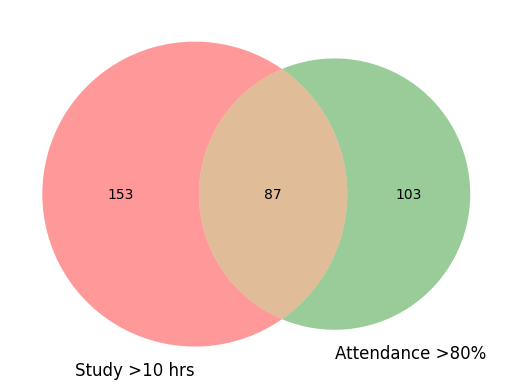

In [15]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

study = set(df[df['study_hours'] > 10].index)
attendance = set(df[df['attendance'] > 80].index)

venn2([study, attendance], set_labels=('Study >10 hrs', 'Attendance >80%'))
plt.show()

## Q5: Contingency Table & Probability

In [16]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
print(table)

joint_prob = table.loc['Yes','Pass'] / len(df)
marginal_prob = df['pass_binary'].mean()
conditional_prob = table.loc['Yes','Pass'] / table.loc['Yes'].sum()

print("Joint Probability:", joint_prob)
print("Marginal Probability:", marginal_prob)
print("Conditional Probability:", conditional_prob)

final_exam_pass   Fail  Pass
group_discussion            
No                  84   116
Yes                 97   203
Joint Probability: 0.406
Marginal Probability: 0.638
Conditional Probability: 0.6766666666666666


## Q7: Bayes Theorem

In [17]:
# Given values
P_H = 0.60
P_P_given_H = 0.70
P_P_given_notH = 0.40

P_notH = 1 - P_H

# Total Probability
P_P = (P_P_given_H * P_H) + (P_P_given_notH * P_notH)

# Bayes Theorem
P_H_given_P = (P_P_given_H * P_H) / P_P

print("P(Pass | High Attendance):", P_H_given_P)

P(Pass | High Attendance): 0.7241379310344827
